# Standard And Recursive QFT

This notebook lets you run the standard QFT method and recursive QFT section by section, inspect amplitudes, compare Aer counts, and view transpiled circuits.


In [1]:
import numpy as np
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Operator, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

try:
    import matplotlib.pyplot as plt
    HISTOGRAMS_AVAILABLE = True
except Exception:
    plt = None
    HISTOGRAMS_AVAILABLE = False

from forward_qft import build_standard_qft, build_recursive_qft, qft_on_amplitudes
from qft_sampler_utils import (
    build_measured_qft_circuit,
    build_sample_amplitudes,
    sample_aer_counts,
    sample_noisy_aer_counts,
    select_fake_backend,
    total_variation_distance,
)
from qft_visualization_utils import show_circuit


def show_histogram(data, legend, title, top_n=12):
    print(f"\n{title}")
    all_labels = sorted({label for counts in data for label, value in counts.items() if value > 0})
    all_labels.sort(key=lambda label: sum(counts.get(label, 0) for counts in data), reverse=True)
    labels = all_labels[:top_n]

    if not HISTOGRAMS_AVAILABLE:
        print("matplotlib is not installed in this environment, so showing raw counts instead.")
        for series_label, counts in zip(legend, data):
            filtered = {label: counts.get(label, 0) for label in labels}
            print(series_label + ":", filtered)
        return

    width = 0.8 / max(len(data), 1)
    x = np.arange(len(labels), dtype=float)
    fig_width = max(12, len(labels) * 1.2)
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    for index, (series_label, counts) in enumerate(zip(legend, data)):
        values = [counts.get(label, 0) for label in labels]
        offset = (index - (len(data) - 1) / 2) * width
        bars = ax.bar(x + offset, values, width=width, label=series_label)
        for bar, value in zip(bars, values):
            if value > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + 0.5,
                    str(value),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    rotation=0,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Counts")
    subtitle = f"Top {len(labels)} outcomes" if len(labels) < len(all_labels) else "All non-zero outcomes"
    ax.set_title(f"{title} ({subtitle})")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

    if len(labels) < len(all_labels):
        print(f"Showing the top {len(labels)} outcomes out of {len(all_labels)} non-zero outcomes.")


In [2]:
num_qubits = 3
shots = 256
sample_amplitudes = build_sample_amplitudes(num_qubits)

standard_qft = build_standard_qft(num_qubits)
recursive_qft = build_recursive_qft(num_qubits)

reference = QuantumCircuit(num_qubits)
reference.append(QFTGate(num_qubits), range(num_qubits))

print("Standard matches Qiskit's QFTGate:", Operator(standard_qft).equiv(Operator(reference)))
print("Recursive matches Qiskit's QFTGate:", Operator(recursive_qft).equiv(Operator(reference)))


Standard matches Qiskit's QFTGate: True
Recursive matches Qiskit's QFTGate: True


In [3]:
transformed = qft_on_amplitudes(sample_amplitudes)

standard_input = QuantumCircuit(num_qubits)
standard_input.initialize(sample_amplitudes, range(num_qubits))
standard_input.compose(standard_qft, inplace=True)

recursive_input = QuantumCircuit(num_qubits)
recursive_input.initialize(sample_amplitudes, range(num_qubits))
recursive_input.compose(recursive_qft, inplace=True)

standard_output = Statevector.from_instruction(standard_input).data
recursive_output = Statevector.from_instruction(recursive_input).data

print("Input amplitudes:")
print(np.array2string(sample_amplitudes, precision=4, suppress_small=True))
print("\nQFT amplitudes from the DFT formula:")
print(np.array2string(transformed, precision=4, suppress_small=True))
print("\nQFT amplitudes from the standard method:")
print(np.array2string(standard_output, precision=4, suppress_small=True))
print("\nQFT amplitudes from the recursive method:")
print(np.array2string(recursive_output, precision=4, suppress_small=True))


Input amplitudes:
[0.07   0.14   0.21   0.2801 0.3501 0.4201 0.4901 0.5601]

QFT amplitudes from the DFT formula:
[ 0.8911+0.j    -0.099 -0.239j -0.099 -0.099j -0.099 -0.041j
 -0.099 +0.j    -0.099 +0.041j -0.099 +0.099j -0.099 +0.239j]

QFT amplitudes from the standard method:
[ 0.8911+0.j    -0.099 -0.239j -0.099 -0.099j -0.099 -0.041j
 -0.099 +0.j    -0.099 +0.041j -0.099 +0.099j -0.099 +0.239j]

QFT amplitudes from the recursive method:
[ 0.8911+0.j    -0.099 -0.239j -0.099 -0.099j -0.099 -0.041j
 -0.099 +0.j    -0.099 +0.041j -0.099 +0.099j -0.099 +0.239j]



Standard QFT circuit


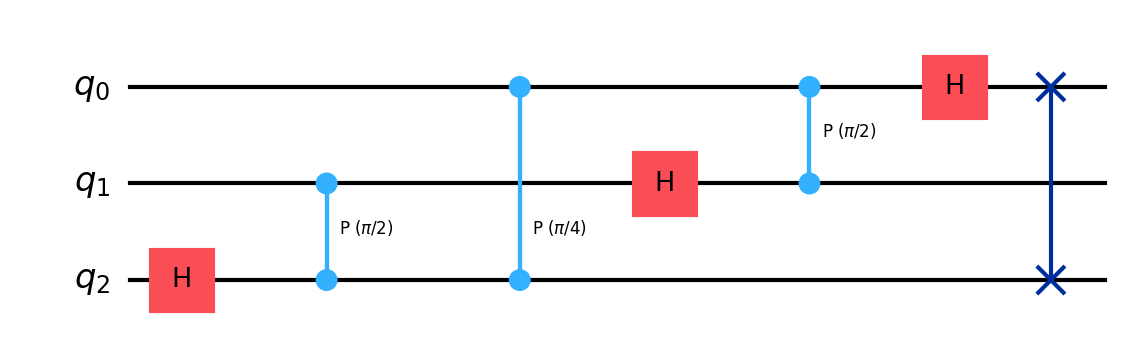


Recursive QFT circuit


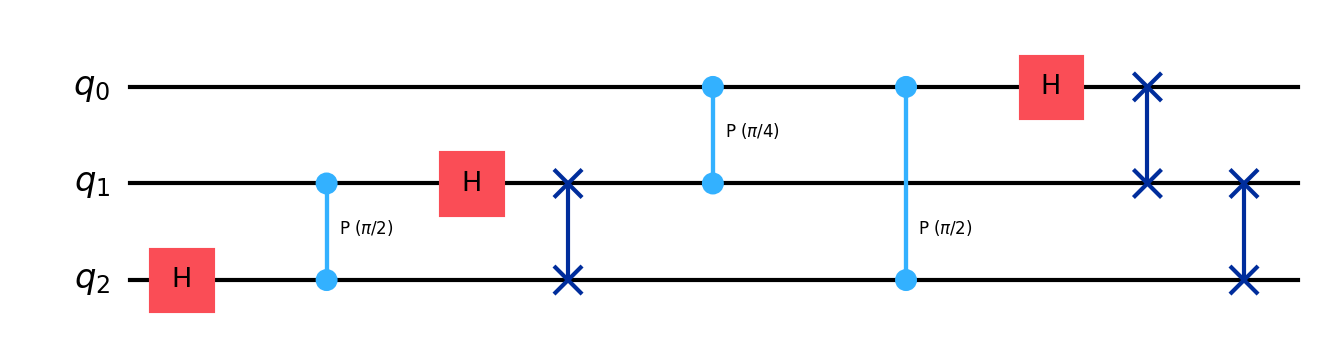

In [4]:
show_circuit(standard_qft, "Standard QFT circuit")
show_circuit(recursive_qft, "Recursive QFT circuit")


Using fake backend: fake_manila
Ideal Aer TVD between methods: 0.0273
Standard ideal vs noisy TVD: 0.2266
Recursive ideal vs noisy TVD: 0.1875

Ideal Aer counts


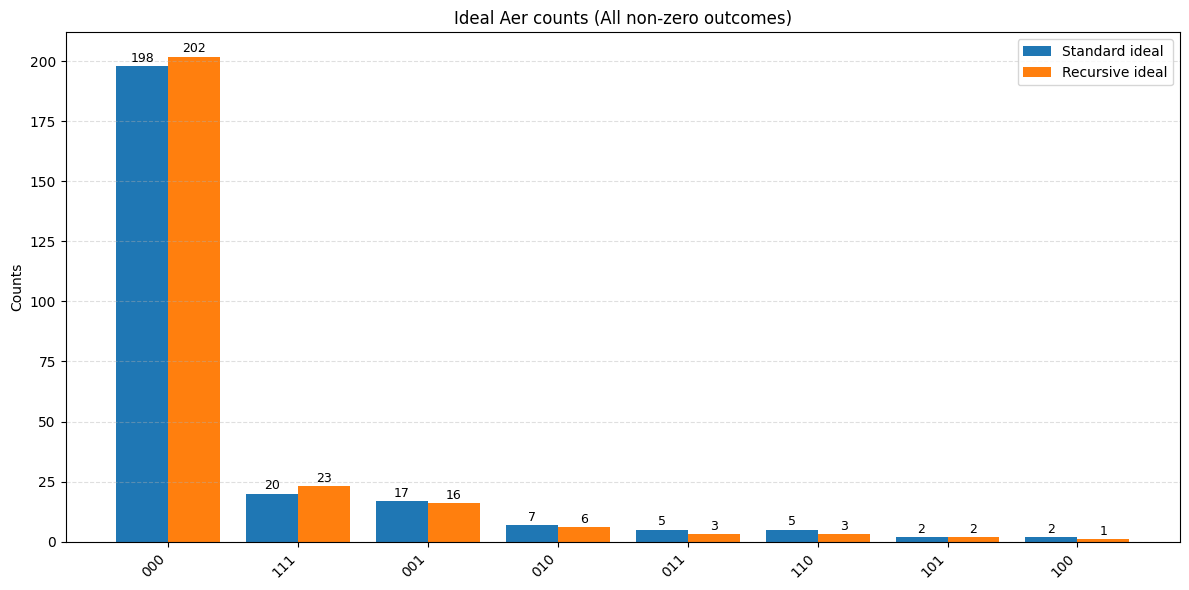


Noisy Aer counts


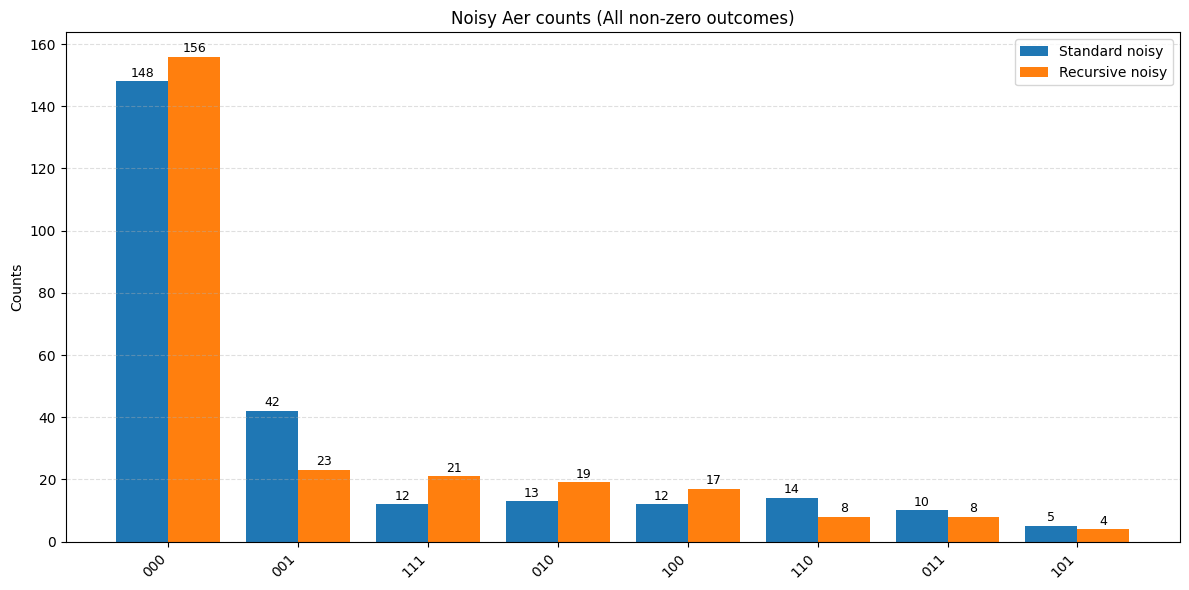

In [5]:
backend = select_fake_backend(num_qubits)
print("Using fake backend:", backend.name)

standard_measured = build_measured_qft_circuit(sample_amplitudes, standard_qft)
recursive_measured = build_measured_qft_circuit(sample_amplitudes, recursive_qft)

standard_ideal_counts = sample_aer_counts(standard_measured, shots=shots)
recursive_ideal_counts = sample_aer_counts(recursive_measured, shots=shots)
standard_noisy_counts = sample_noisy_aer_counts(standard_measured, backend=backend, shots=shots)
recursive_noisy_counts = sample_noisy_aer_counts(recursive_measured, backend=backend, shots=shots)

print("Ideal Aer TVD between methods:", round(total_variation_distance(standard_ideal_counts, recursive_ideal_counts), 4))
print("Standard ideal vs noisy TVD:", round(total_variation_distance(standard_ideal_counts, standard_noisy_counts), 4))
print("Recursive ideal vs noisy TVD:", round(total_variation_distance(recursive_ideal_counts, recursive_noisy_counts), 4))

show_histogram(
    [standard_ideal_counts, recursive_ideal_counts],
    legend=["Standard ideal", "Recursive ideal"],
    title="Ideal Aer counts",
)
show_histogram(
    [standard_noisy_counts, recursive_noisy_counts],
    legend=["Standard noisy", "Recursive noisy"],
    title="Noisy Aer counts",
)



Standard QFT transpiled


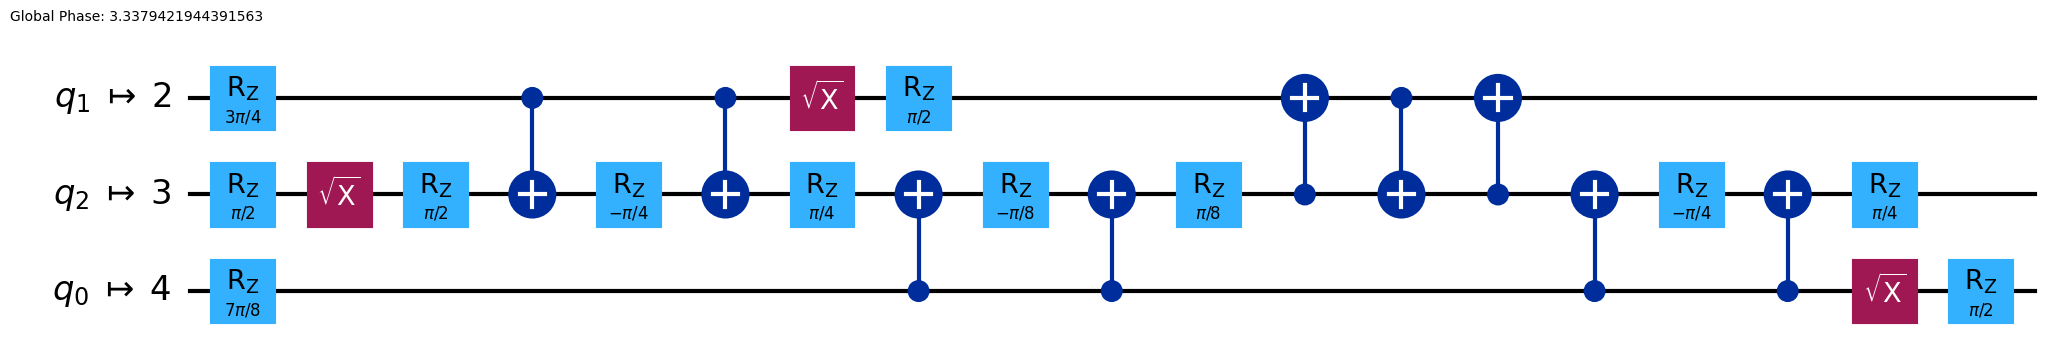


Recursive QFT transpiled


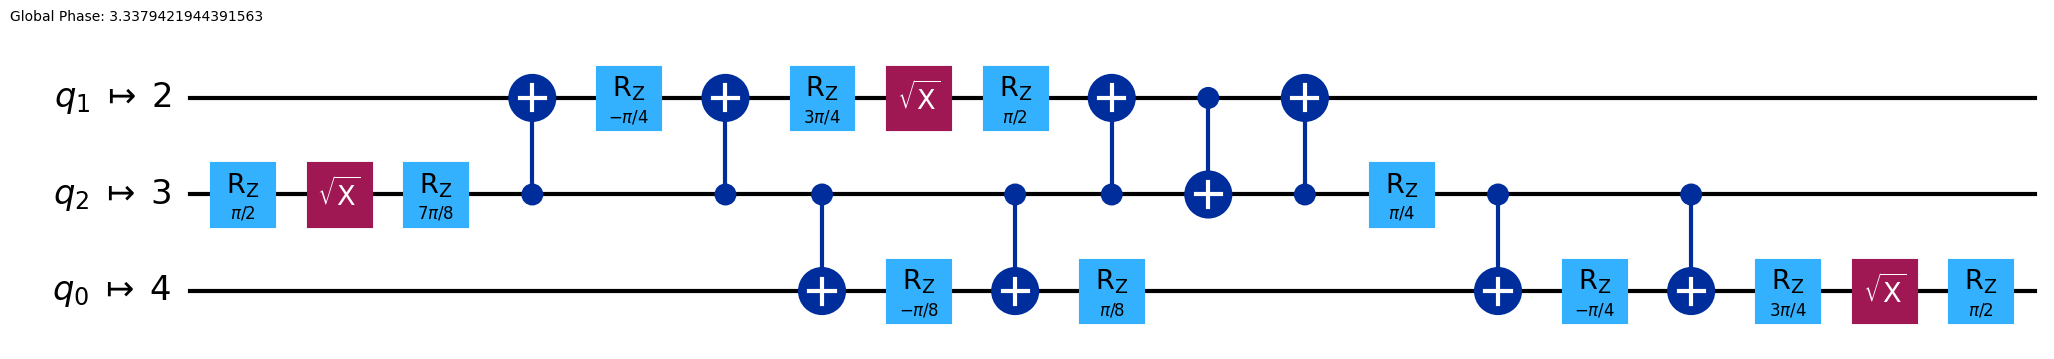

Standard transpiled ops: {'rz': 12, 'cx': 9, 'sx': 3}
Recursive transpiled ops: {'rz': 11, 'cx': 9, 'sx': 3}
Standard depth: 19
Recursive depth: 19


In [6]:
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=backend)
standard_transpiled = pass_manager.run(standard_qft)
recursive_transpiled = pass_manager.run(recursive_qft)

show_circuit(standard_transpiled, "Standard QFT transpiled")
show_circuit(recursive_transpiled, "Recursive QFT transpiled")

print("Standard transpiled ops:", dict(standard_transpiled.count_ops()))
print("Recursive transpiled ops:", dict(recursive_transpiled.count_ops()))
print("Standard depth:", standard_transpiled.depth())
print("Recursive depth:", recursive_transpiled.depth())
